# <center> DS_PROD-4. A/B-тестирование

### 4. Анализ результатов A/B-тестирования: кумулятивные метрики

In [761]:
#Импорты

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportions_chisquare
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import norm
from scipy.stats import t

In [762]:
# Чтение данных
ab_data = pd.read_csv('data/ab_data.zip')
ab_data.head()

,user_id,timestamp,group,converted
0,851104,2017-01-21,A,0
1,804228,2017-01-12,A,0
2,661590,2017-01-11,B,0
3,853541,2017-01-08,B,0
4,864975,2017-01-21,A,1


user_id - идентификатор пользователя, зашедшего на сайт  
timestamp - дата события  
group - группа теста (контрольная или тестовая)  
converted - совершил пользователь целевое действие (нажатие кнопки «добавить в корзину» на сопутствующем товаре) или нет. 1 — да, 0 — нет.

In [763]:
ab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290482 entries, 0 to 290481
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    290482 non-null  int64 
 1   timestamp  290482 non-null  object
 2   group      290482 non-null  object
 3   converted  290482 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 8.9+ MB


In [764]:
#Перевод столбца с маркировкой времени в timestamp
ab_data['timestamp'] = pd.to_datetime(ab_data['timestamp'], format='%Y-%m-%d')

In [765]:
#Получение таблицы ежедневных действий пользователей

daily_data = ab_data.groupby(['timestamp', 'group']).agg({'user_id':'count', 'converted':'sum'}).reset_index().rename(columns={'user_id':'users_count'})
daily_data.head()

,timestamp,group,users_count,converted
0,2017-01-02,A,2851,357
1,2017-01-02,B,2848,339
2,2017-01-03,A,6584,749
3,2017-01-03,B,6620,754
4,2017-01-04,A,6573,797


In [766]:
#Получение дневной конверсии
daily_data['conversion'] = round((daily_data['users_count']-(daily_data['users_count']-daily_data['converted']))/daily_data['users_count']*100, 2)

#Задание 4.1
print('Конверсия 5 января 2017 года в группе А:\n', 
      daily_data[(daily_data['timestamp']=='2017-01-05') & (daily_data['group']=='A')]['conversion'])

Конверсия 5 января 2017 года в группе А:
 6    12.32
Name: conversion, dtype: float64


In [767]:
display(daily_data.head())
display(daily_data.info())

,timestamp,group,users_count,converted,conversion
0,2017-01-02,A,2851,357,12.52
1,2017-01-02,B,2848,339,11.90
2,2017-01-03,A,6584,749,11.38
3,2017-01-03,B,6620,754,11.39
4,2017-01-04,A,6573,797,12.13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    46 non-null     datetime64[ns]
 1   group        46 non-null     object        
 2   users_count  46 non-null     int64         
 3   converted    46 non-null     int64         
 4   conversion   46 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 1.9+ KB


None

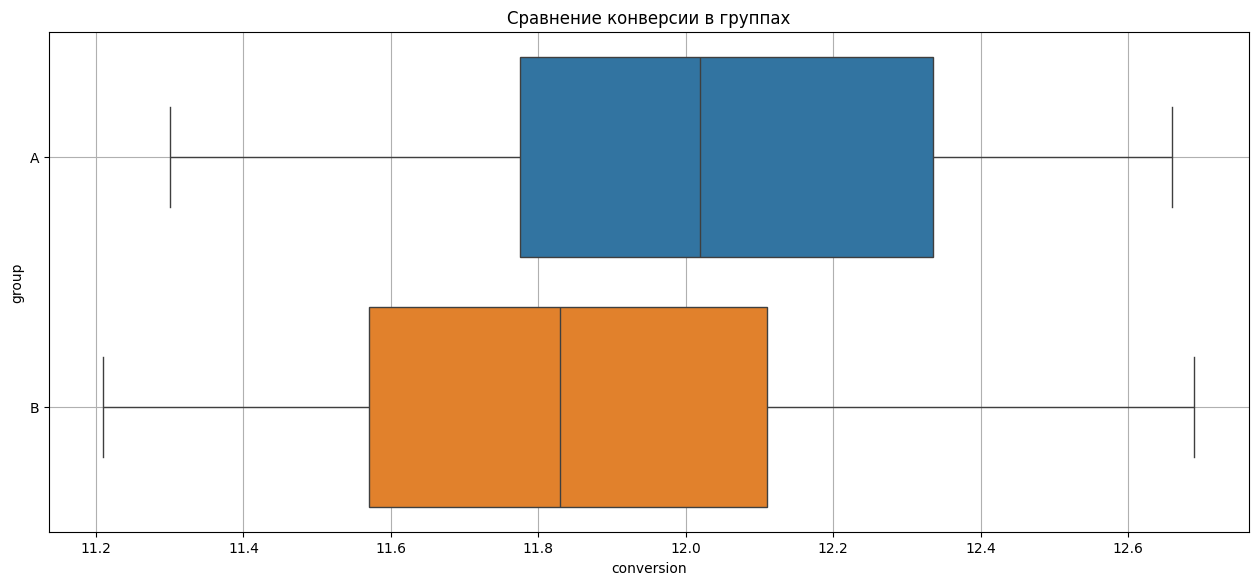

In [768]:
#Диаграмма ежедневной конверсии
fig = plt.figure(figsize=(12,5))
ax = fig.add_axes([1,1,1,1])
sns.boxplot(data=daily_data, x='conversion', y='group', hue='group', ax=ax)
ax.set_title('Сравнение конверсии в группах')
ax.grid(True);

In [769]:
#Таблица со средними и медианными значениями по группам
conversion_piv = daily_data.groupby('group')['conversion'].agg(['mean', 'median'])
display(conversion_piv)

,mean,median
group,,
A,12.033478,12.02
B,11.872174,11.83


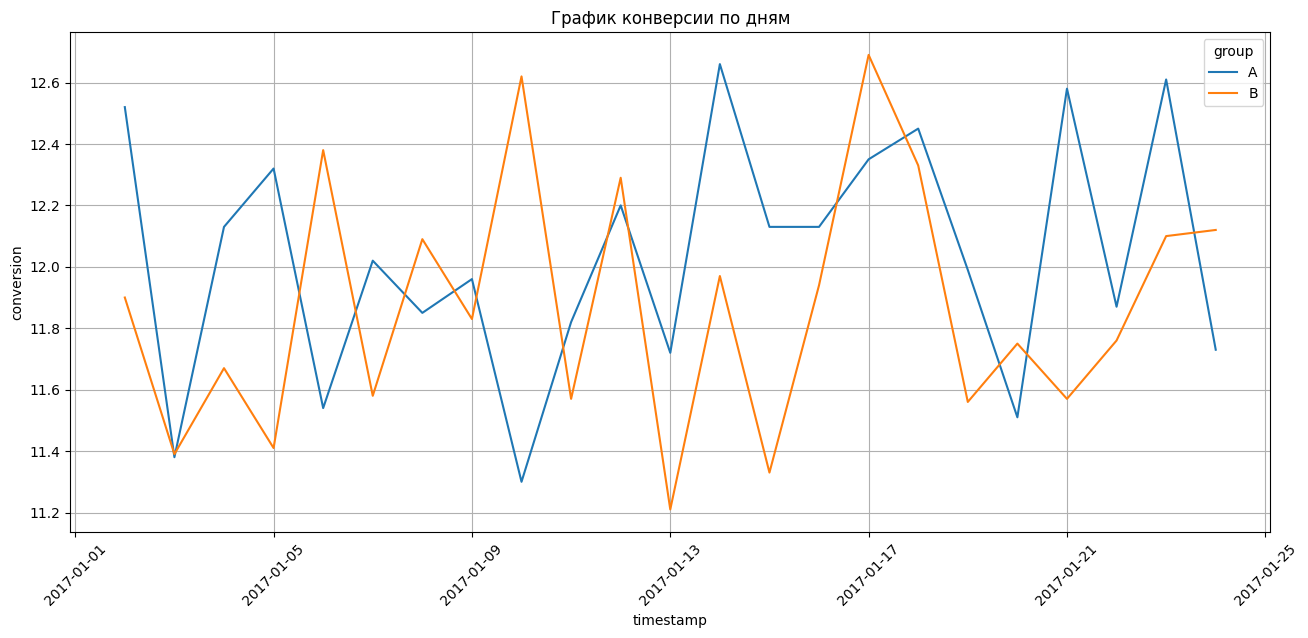

In [770]:
#График визуальной кумулятивной метрики

fig = plt.figure(figsize=(12,5))
ax = fig.add_axes([1,1,1,1])
sns.lineplot(
    data=daily_data,
    x='timestamp',
    y='conversion',
    ax=ax,
    hue='group'
)
ax.set_title('График конверсии по дням')
#Наклон значений по х
ax.xaxis.set_tick_params(rotation=45)
ax.grid(True)

In [771]:
#Проверка работы pandas.cumsum()
#Выделим группу А
daily_data_a = daily_data[daily_data['group']=='A']
daily_data_a.loc[:, 'cum_users_count'] = daily_data_a['users_count'].cumsum()
display(daily_data_a[['timestamp', 'users_count', 'cum_users_count']].head())

C:\Users\telis\AppData\Local\Temp\ipykernel_8760\527214348.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data_a.loc[:, 'cum_users_count'] = daily_data_a['users_count'].cumsum()


,timestamp,users_count,cum_users_count
0,2017-01-02,2851,2851
2,2017-01-03,6584,9435
4,2017-01-04,6573,16008
6,2017-01-05,6419,22427
8,2017-01-06,6604,29031


In [772]:
#Теперь конверсию, сумму совершенных действий и сумму количества пользователей
daily_data['cum_users_count'] = daily_data.groupby(['group'])['users_count'].cumsum()
daily_data['cum_converted'] = daily_data.groupby(['group'])['converted'].cumsum()
daily_data['cum_conversion'] = daily_data['cum_converted']/daily_data['cum_users_count'] * 100
display(daily_data.head())

,timestamp,group,users_count,converted,conversion,cum_users_count,cum_converted,cum_conversion
0,2017-01-02,A,2851,357,12.52,2851,357,12.521922
1,2017-01-02,B,2848,339,11.90,2848,339,11.903090
2,2017-01-03,A,6584,749,11.38,9435,1106,11.722311
3,2017-01-03,B,6620,754,11.39,9468,1093,11.544149
4,2017-01-04,A,6573,797,12.13,16008,1903,11.887806


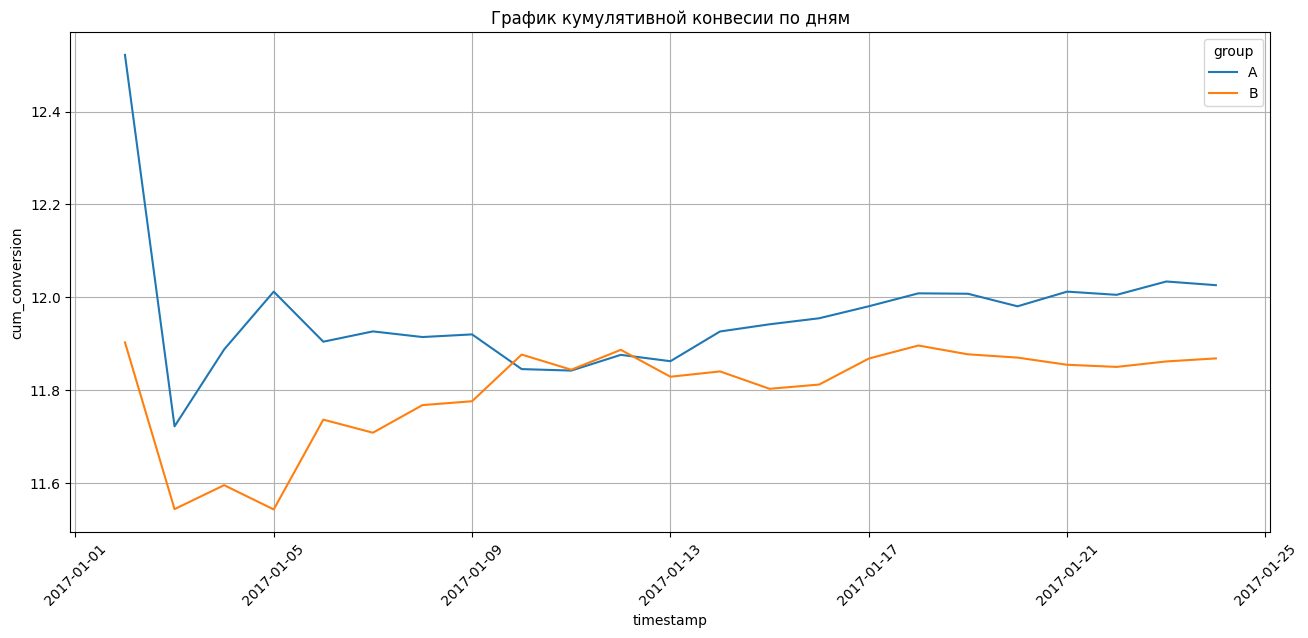

In [773]:
#График кумулятивной конверсии

fig = plt.figure(figsize=(12,5))
ax = fig.add_axes([1,1,1,1])
sns.lineplot(data=daily_data, x='timestamp', y='cum_conversion', hue='group', ax=ax)
ax.set_title('График кумулятивной конвесии по дням')
ax.xaxis.set_tick_params(rotation=45)
ax.grid(True);

In [774]:
#Данные для практики
sample_a = pd.read_csv('data/ab_test-redesign_sample_a.zip')
sample_b = pd.read_csv('data/ab_test-redesign_sample_b.zip')
display(sample_a.head())
display(sample_b.head())

,date,cid,transactions,revenue,group
0,2020-11-06,1.001648e+09,0,0,A
1,2020-11-06,1.001936e+09,0,0,A
2,2020-11-06,1.003214e+08,0,0,A
3,2020-11-06,1.004393e+09,0,0,A
4,2020-11-06,1.006382e+09,0,0,A


,date,cid,transactions,revenue,group
0,2020-11-06,1.000135e+09,0,0,B
1,2020-11-06,1.001648e+09,0,0,B
2,2020-11-06,1.003214e+08,0,0,B
3,2020-11-06,1.003652e+09,0,0,B
4,2020-11-06,1.003833e+09,0,0,B


date — дата наблюдения;  
cid — идентификатор посетителя;  
transactions — количество совершённых целевых действий (транзакций);  
revenue — сумма покупки;  
group — группа (тестовая — А, контрольная — B).

In [775]:
display(sample_a.info())
display(sample_b.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61571 entries, 0 to 61570
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          61571 non-null  object 
 1   cid           61571 non-null  float64
 2   transactions  61571 non-null  int64  
 3   revenue       61571 non-null  int64  
 4   group         61571 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 2.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61383 entries, 0 to 61382
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          61383 non-null  object 
 1   cid           61383 non-null  float64
 2   transactions  61383 non-null  int64  
 3   revenue       61383 non-null  int64  
 4   group         61383 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 2.3+ MB


None

In [776]:
#Задание 4.6
#Преобразование date в datetime
sample_a['date'] = pd.to_datetime(sample_a['date'], format='%Y-%m-%d')
sample_b['date'] = pd.to_datetime(sample_b['date'], format='%Y-%m-%d')

#Таблица с ежедневными показателями
daily_data_a = sample_a.groupby(by=['date', 'group']).agg({'transactions': 'sum', 'revenue': 'sum', 'cid': 'count'}).reset_index().rename(columns={'cid': 'users_count'})
daily_data_b = sample_b.groupby(by=['date', 'group']).agg({'transactions': 'sum', 'revenue': 'sum', 'cid': 'count'}).reset_index().rename(columns={'cid': 'users_count'})
display('Группа А:', daily_data_a.head(3)) #Ответ
display('Группа B:', daily_data_b.head(3))

'Группа А:'

,date,group,transactions,revenue,users_count
0,2020-11-06,A,16,1577279,2576
1,2020-11-07,A,23,1721886,2704
2,2020-11-08,A,25,846051,3354


'Группа B:'

,date,group,transactions,revenue,users_count
0,2020-11-06,B,19,996645,2499
1,2020-11-07,B,19,555499,2804
2,2020-11-08,B,24,3044842,3291


In [777]:
#Задание 4.7
#Добавление кумулятивных метрик
daily_data_a['cum_users_count'] = daily_data_a['users_count'].cumsum()
daily_data_a['cum_revenue'] = daily_data_a['revenue'].cumsum()
daily_data_a['cum_transactions'] = daily_data_a['transactions'].cumsum()

daily_data_b['cum_users_count'] = daily_data_b['users_count'].cumsum()
daily_data_b['cum_revenue'] = daily_data_b['revenue'].cumsum()
daily_data_b['cum_transactions'] = daily_data_b['transactions'].cumsum()

#Для будущих заданий
daily_data_a['trans_conversion'] = round(daily_data_a['cum_transactions']/daily_data_a['cum_users_count'] * 100, 2)
daily_data_b['trans_conversion'] = round(daily_data_b['cum_transactions']/daily_data_b['cum_users_count'] * 100, 2)
daily_data_a['daily_avg_receipt'] = round(daily_data_a['cum_revenue']/daily_data_a['cum_transactions'], 2)
daily_data_b['daily_avg_receipt'] = round(daily_data_b['cum_revenue']/daily_data_b['cum_transactions'], 2)

display('Группа А:', daily_data_a.head(3))
display('Группа B:', daily_data_b.head(3))

cum_stats_a = daily_data_a.groupby(by='group').agg({'cum_users_count': 'sum', 'cum_revenue': 'sum', 'cum_transactions': 'sum'})
cum_stats_a['conv_transactions'] = round(cum_stats_a['cum_transactions']/cum_stats_a['cum_users_count'] * 100, 2)
cum_stats_a['cum_avg_receipt'] = round(cum_stats_a['cum_revenue']/cum_stats_a['cum_transactions'], 2)
cum_stats_b = daily_data_b.groupby(by='group').agg({'cum_users_count': 'sum', 'cum_revenue': 'sum', 'cum_transactions': 'sum'})
cum_stats_b['conv_transactions'] = round(cum_stats_b['cum_transactions']/cum_stats_b['cum_users_count'] * 100, 2)
cum_stats_b['cum_avg_receipt'] = round(cum_stats_b['cum_revenue']/cum_stats_b['cum_transactions'], 2)
cum_stats = pd.concat([cum_stats_a, cum_stats_b])
cum_stats

'Группа А:'

,date,group,transactions,revenue,users_count,cum_users_count,cum_revenue,cum_transactions,trans_conversion,daily_avg_receipt
0,2020-11-06,A,16,1577279,2576,2576,1577279,16,0.62,98579.94
1,2020-11-07,A,23,1721886,2704,5280,3299165,39,0.74,84593.97
2,2020-11-08,A,25,846051,3354,8634,4145216,64,0.74,64769.00


'Группа B:'

,date,group,transactions,revenue,users_count,cum_users_count,cum_revenue,cum_transactions,trans_conversion,daily_avg_receipt
0,2020-11-06,B,19,996645,2499,2499,996645,19,0.76,52455.00
1,2020-11-07,B,19,555499,2804,5303,1552144,38,0.72,40845.89
2,2020-11-08,B,24,3044842,3291,8594,4596986,62,0.72,74144.94


,cum_users_count,cum_revenue,cum_transactions,conv_transactions,cum_avg_receipt
group,,,,,
A,568184,241662109,4052,0.71,59640.20
B,564879,302519870,4295,0.76,70435.36


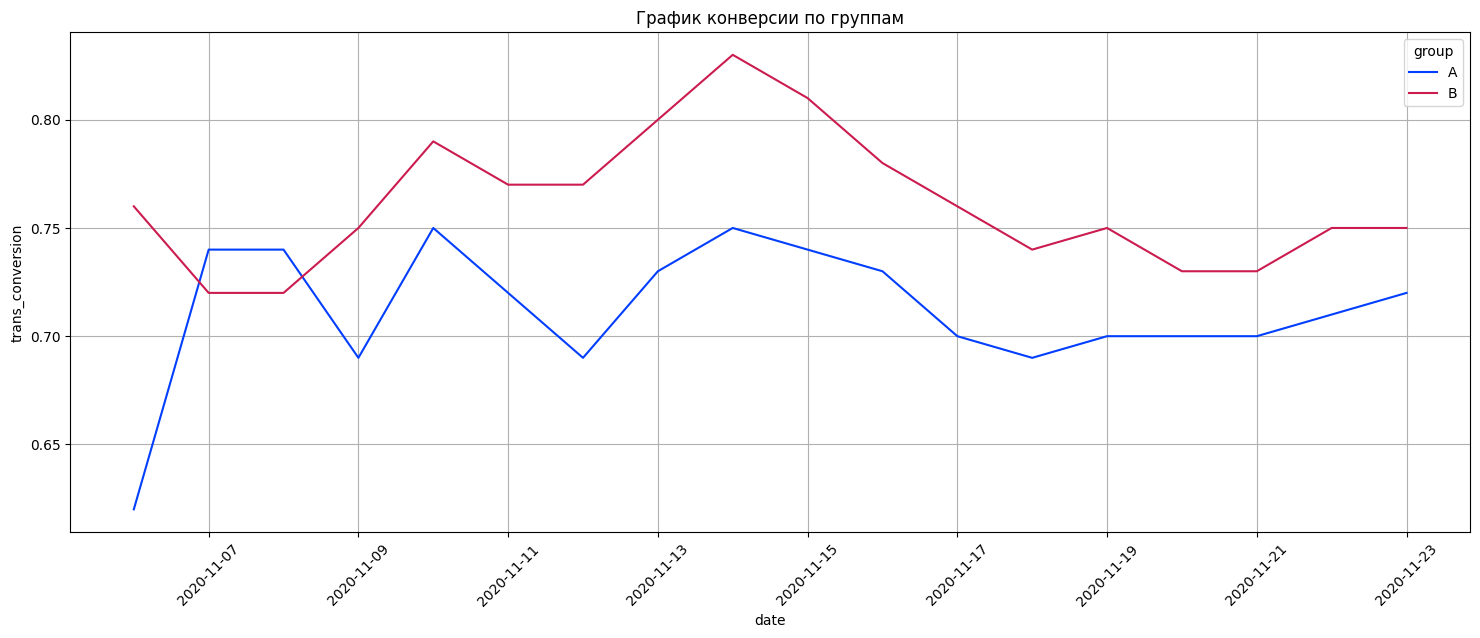

In [778]:
#Задание 4.8
fig = plt.figure(figsize=(14,5))
ax = fig.add_axes([1,1,1,1])
ax = sns.lineplot(data=daily_data_a, x='date', y='trans_conversion', hue='group', palette='bright')
sns.color_palette
ax = sns.lineplot(data=daily_data_b, x='date', y='trans_conversion', hue='group', palette='rocket')
ax.xaxis.set_tick_params(rotation=45)
ax.set_title('График конверсии по группам')
ax.grid(True)

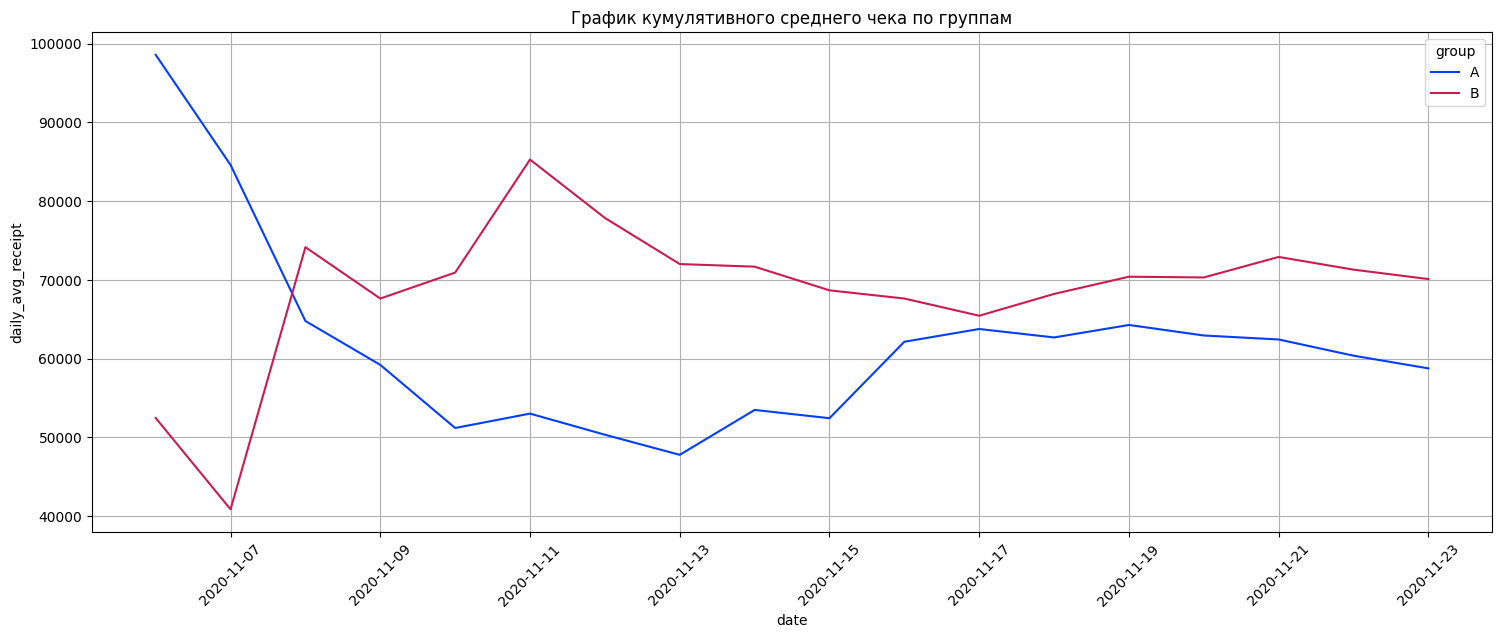

In [779]:
#Задание 4.9
fig = plt.figure(figsize=(14,5))
ax = fig.add_axes([1,1,1,1])
ax = sns.lineplot(data=daily_data_a, x='date', y='daily_avg_receipt', hue='group', palette='bright')
ax = sns.lineplot(data=daily_data_b, x='date', y='daily_avg_receipt', hue='group', palette='rocket')
ax.xaxis.set_tick_params(rotation=45)
ax.set_title('График кумулятивного среднего чека по группам')
ax.grid(True)

### 5. Анализ результатов A/B-тестирования: статистические тесты

СТАТИСТИЧЕСКИЕ ТЕСТЫ ДЛЯ КОНВЕРСИИ

In [780]:
#Общая таблица с количеством успешного выполнения условия и общим количеством возможностей его выполнения
converted_piv = ab_data.groupby('group')['converted'].agg(['sum', 'count'])
display(converted_piv)

,sum,count
group,,
A,17467,145241
B,17238,145241


In [781]:
#Z-пропорция
alpha = 0.05 # уровень значимости
# вычисляем значение p-value для z-теста для пропорций
_, p_value = proportions_ztest(
    count=converted_piv['sum'], #число «успехов»
    nobs=converted_piv['count'], #общее число наблюдений
    alternative='two-sided',
)
# выводим результат на экран
print('p-value: ', round(p_value, 3))
# сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value:  0.19
У нас нет оснований отвергнуть нулевую гипотезу


In [782]:
#Z-пропорция
alpha = 0.05 # уровень значимости
# вычисляем значение p-value для Z-теста для пропорций
_, p_value = proportions_ztest(
    count=converted_piv['sum'], # число «успехов»
    nobs=converted_piv['count'], # общее число наблюдений
    alternative='larger' # правосторонняя альтернативная гипотеза
)
# выводим результат на экран
print('p-value: ', round(p_value, 3))
# сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value:  0.095
У нас нет оснований отвергнуть нулевую гипотезу


In [783]:
#Хи-квадрат
alpha = 0.05 # уровень значимости
# вычисляем значение p-value для Z-теста для пропорций
_, p_value, c = proportions_chisquare(
    count=converted_piv['sum'], #число «успехов»
    nobs=converted_piv['count'] #общее число наблюдений
)
# выводим результат на экран
print('p-value: ', round(p_value, 3))
# сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value:  0.19
У нас нет оснований отвергнуть нулевую гипотезу


Параметрические тесты

In [784]:
time_data = pd.read_excel('data/time_delta.xlsx')
display(time_data.head(3))

,time(A),time(B)
0,435.0,549.2
1,454.5,630.2
2,447.0,437.2


In [785]:
time_data[['time(A)', 'time(B)']].agg(['mean', 'median'])

,time(A),time(B)
mean,492.90,595.406667
median,482.25,600.400000


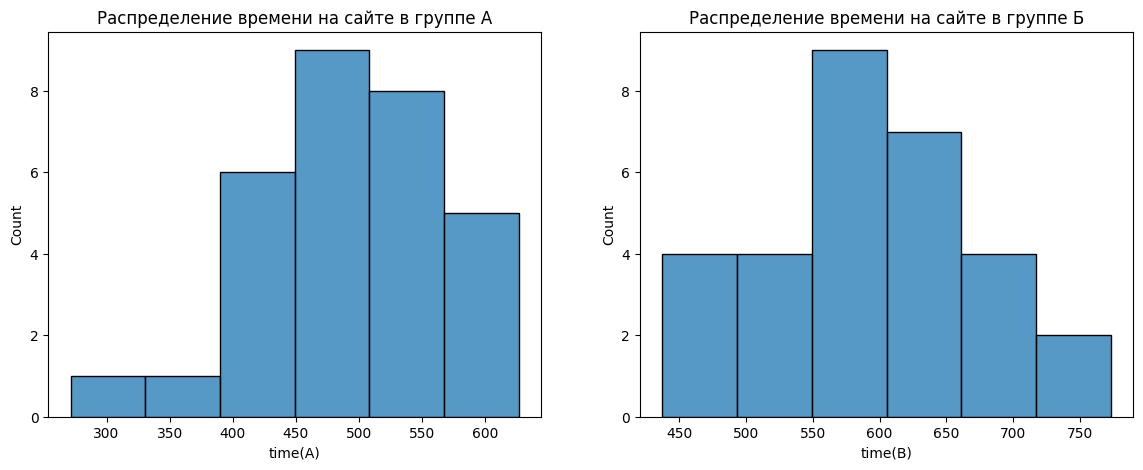

In [786]:
#Создание графиков распределения времени для двух групп
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.histplot(x='time(A)', data=time_data, ax=axes[0])
sns.histplot(x='time(B)', data=time_data, ax=axes[1])
axes[0].set_title('Распределение времени на сайте в группе А');
axes[1].set_title('Распределение времени на сайте в группе Б');

In [787]:
alpha = 0.05 # уровень значимости
# вычисляем результат теста Шапиро — Уилка для выборок
shapiro_result_a = shapiro(time_data['time(A)'])
shapiro_result_b = shapiro(time_data['time(B)'])
print('p-value группы А', round(shapiro_result_a.pvalue, 2))
print('p-value группы B', round(shapiro_result_b.pvalue, 2))

# сравниваем полученное p-value для группы А с уровнем значимости
if shapiro_result_a.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе А отлично от нормального")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе А является нормальным")

# сравниваем полученное p-value для группы B с уровнем значимости
if shapiro_result_b.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе B отлично от нормального")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе B является нормальным")

p-value группы А 0.43
p-value группы B 0.12
Принимаем нулевую гипотезу. Распределение в группе А является нормальным
Принимаем нулевую гипотезу. Распределение в группе B является нормальным


In [788]:
alpha = 0.05 #уровень значимости
# вычисляем результат T-теста для выборок
results = ttest_ind(
    a=time_data['time(A)'],
    b=time_data['time(B)'],
    alternative='two-sided'
)
print('p-value:', round(results.pvalue, 2))

# сравниваем полученное p-value с уровнем значимости
if results.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value: 0.0
Отвергаем нулевую гипотезу в пользу альтернативной


Непараметрические тесты

In [789]:
#Читаем данные для непараметричесих тестов
check_data = pd.read_excel('data/check_data.xlsx')
display(check_data.head(3))
display(check_data.info())

,date,mean_check_a,mean_check_b
0,2020-11-06,68701.239649,88665.123322
1,2020-11-07,26136.309375,46230.394893
2,2020-11-08,119470.770656,139356.451490


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          18 non-null     datetime64[ns]
 1   mean_check_a  18 non-null     float64       
 2   mean_check_b  18 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 564.0 bytes


None

In [790]:
check_data[['mean_check_a', 'mean_check_b']].agg(['mean', 'median'])

,mean_check_a,mean_check_b
mean,76684.763071,96658.897304
median,62883.707793,82854.201467


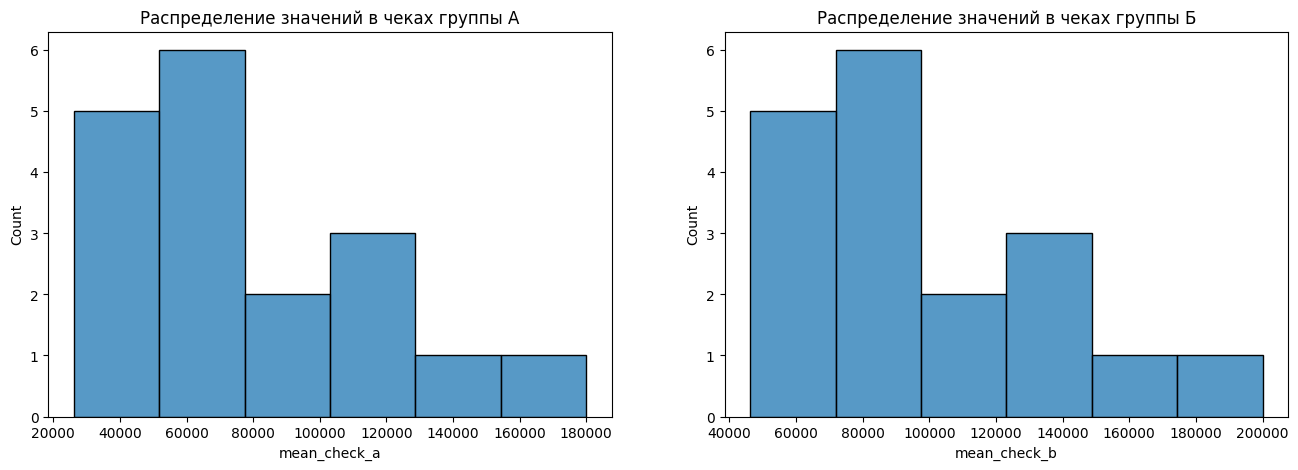

In [791]:
#Построим график распределения групп

fig, axes = plt.subplots(1,2, figsize=(16,5))
sns.histplot(x='mean_check_a', data=check_data, ax=axes[0])
sns.histplot(x='mean_check_b', data=check_data, ax=axes[1])
axes[0].set_title('Распределение значений в чеках группы А');
axes[1].set_title('Распределение значений в чеках группы Б');

In [792]:
#На всякий случай

alpha = 0.05 # уровень значимости
# вычисляем результат теста Шапиро — Уилка для выборок
shapiro_result_a = shapiro(check_data['mean_check_a'])
shapiro_result_b = shapiro(check_data['mean_check_b'])
print('p-value группы А', round(shapiro_result_a.pvalue, 2))
print('p-value группы B', round(shapiro_result_b.pvalue, 2))

# сравниваем полученное p-value для группы А с уровнем значимости
if shapiro_result_a.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе А отлично от нормального")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе А является нормальным")

# сравниваем полученное p-value для группы B с уровнем значимости
if shapiro_result_b.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе B отлично от нормального")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе B является нормальным")

p-value группы А 0.05
p-value группы B 0.05
Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе А отлично от нормального
Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе B отлично от нормального


In [793]:
#Тест по критерию манна-уитни
alpha = 0.05 # уровень значимости

# вычисляем результат теста Манна — Уитни для выборок
results = mannwhitneyu(
    x=check_data['mean_check_a'],
    y=check_data['mean_check_b'],
    alternative='two-sided'
)
print('p-value:', round(results.pvalue, 2))

# сравниваем полученное p-value с уровнем значимости
if results.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value: 0.06
У нас нет оснований отвергнуть нулевую гипотезу


In [794]:
#Тест по одностороннему U-тесту
alpha = 0.05 # уровень значимости

# вычисляем результат теста Манна — Уитни для выборок
results = mannwhitneyu(
    x=check_data['mean_check_a'],
    y=check_data['mean_check_b'],
    alternative='less' # изменили альтернативную гипотезу
)
print('p-value:', round(results.pvalue, 2))

# сравниваем полученное p-value с уровнем значимости
if results.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value: 0.03
Отвергаем нулевую гипотезу в пользу альтернативной


In [795]:
#Заново загружаем данные для следующих заданий
#Для возможности визуального анализа оставлю предыдущие наборы данных
sample_aa = pd.read_csv('data/ab_test-redesign_sample_a.zip')
sample_bb = pd.read_csv('data/ab_test-redesign_sample_b.zip')

# преобразуем тип столбца date к типу datetime
sample_aa['date'] = pd.to_datetime(sample_aa['date'])
sample_bb['date'] = pd.to_datetime(sample_bb['date'])

display('Группа А:', sample_aa.head(3))
display('Группа Б:', sample_bb.head(3))

'Группа А:'

,date,cid,transactions,revenue,group
0,2020-11-06,1.001648e+09,0,0,A
1,2020-11-06,1.001936e+09,0,0,A
2,2020-11-06,1.003214e+08,0,0,A


'Группа Б:'

,date,cid,transactions,revenue,group
0,2020-11-06,1.000135e+09,0,0,B
1,2020-11-06,1.001648e+09,0,0,B
2,2020-11-06,1.003214e+08,0,0,B


In [796]:
#Задание 5.2
#Z-пропорция
all_sample_data = pd.concat([sample_aa, sample_bb])
conversion_sample_piv = all_sample_data.groupby(by='group')['transactions'].agg(['count', 'sum'])
display(conversion_sample_piv)

alpha = 0.05 # уровень значимости
# вычисляем значение p-value для Z-теста для пропорций
_, p_value = proportions_ztest(
    count=conversion_sample_piv['sum'], # число «успехов»
    nobs=conversion_sample_piv['count'], # общее число наблюдений
    alternative='smaller'
)
# выводим результат на экран
print('p-value: ', round(p_value, 3))
# сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

,count,sum
group,,
A,61571,441
B,61383,463


p-value:  0.218
У нас нет оснований отвергнуть нулевую гипотезу


In [797]:
#Подготовка к заданию 5.3 - вычисление среднего чека
daily_sample_a = sample_a.groupby('date')[['transactions', 'revenue']].sum()
daily_sample_a['mean_check'] = daily_sample_a['revenue']/daily_sample_a['transactions']
daily_sample_b = sample_b.groupby('date')[['transactions', 'revenue']].sum()
daily_sample_b['mean_check'] = daily_sample_b['revenue']/daily_sample_a['transactions']

In [798]:
#Задание 5.3
#Проверка гипотезы о нормальности с помощью шапиро-уилка
alpha = 0.05 # уровень значимости
# вычисляем результат теста Шапиро — Уилка для выборок
shapiro_result_a = shapiro(daily_sample_a['mean_check'])
shapiro_result_b = shapiro(daily_sample_b['mean_check'])
print('p-value группы А', round(shapiro_result_a.pvalue, 2))
print('p-value группы B', round(shapiro_result_b.pvalue, 2))

# сравниваем полученное p-value для группы А с уровнем значимости
if shapiro_result_a.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе А отлично от нормального")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе А является нормальным")

# сравниваем полученное p-value для группы B с уровнем значимости
if shapiro_result_b.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе B отлично от нормального")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе B является нормальным")

p-value группы А 0.01
p-value группы B 0.03
Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе А отлично от нормального
Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе B отлично от нормального


In [799]:
#Задание 5.4
#Тест по критерию манна-уитни
alpha = 0.05 # уровень значимости

# вычисляем результат теста Манна — Уитни для выборок
results = mannwhitneyu(
    x=daily_sample_a['mean_check'],
    y=daily_sample_b['mean_check'],
    alternative='two-sided'
)
print('p-value:', round(results.pvalue, 2))

# сравниваем полученное p-value с уровнем значимости
if results.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
    
print('-'*20)
print('Для случая с большим значением в варианте Б')

#Тест по критерию манна-уитни
alpha = 0.05 # уровень значимости

# вычисляем результат теста Манна — Уитни для выборок
results = mannwhitneyu(
    x=daily_sample_a['mean_check'],
    y=daily_sample_b['mean_check'],
    alternative='greater'
)
print('p-value:', round(results.pvalue, 2))

# сравниваем полученное p-value с уровнем значимости
if results.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")
    
print('-'*20)
print('Для случая с меньшим значением в варианте Б')

#Тест по критерию манна-уитни
alpha = 0.05 # уровень значимости

# вычисляем результат теста Манна — Уитни для выборок
results = mannwhitneyu(
    x=daily_sample_a['mean_check'],
    y=daily_sample_b['mean_check'],
    alternative='less'
)
print('p-value:', round(results.pvalue, 2))

# сравниваем полученное p-value с уровнем значимости
if results.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value: 0.12
У нас нет оснований отвергнуть нулевую гипотезу
--------------------
Для случая с большим значением в варианте Б
p-value: 0.94
У нас нет оснований отвергнуть нулевую гипотезу
--------------------
Для случая с меньшим значением в варианте Б
p-value: 0.06
У нас нет оснований отвергнуть нулевую гипотезу


### Анализ результатов A/B тестирования: доверительные интервалы

Доверительный интервал среднего при известном истинном стандартном отклонении

Задача: Была опрошена случайная выборка из 36 жителей региона об их затратах на продукты питания за последний месяц. Выборочное среднее оказалось равным 16 100 рублей.  
Допустим, откуда-то известно, что истинное стандартное отклонение расходов равно 12 000 рублей.  
Нам нужно построить доверительный интервал для истинных средних расходов жителя данного региона на продукты питания в месяц. Интервал должен определять истинное значение с надежностью в 95 %.

In [800]:
n = 36 # размер выборки
x_mean = 16100 # выборочное среднее
sigma = 12000 # истинное стандартное отклонение
gamma = 0.95 # уровень надёжности
alpha = 1 - gamma # уровень значимости

In [801]:
z_crit = -norm.ppf(alpha/2)  #z-критическое !Обязательно брать отрицательный вариант
print(z_crit)

1.959963984540054


In [ ]:
from scipy.stats import norm

def z_mean_conf_interval(x_mean, sigma, n, gamma=0.95, return_z_crit=False):
    
    """Функция для вычисления нижней и верхней границы доверительного
    интервала среднего при известном стандартном отклонении. Возвращает 
    кортеж - левую и правую (нижнюю и верхнюю) границу.

    Args:
        x_mean (int/float): Выборочное среднее
        sigma (int/float): Истинное стандартное отклонение
        n (int): Размер выборки
        gamma (float, optional): Уровень надёжности. Defaults to 0.95.
        return_z_crit (bool): Возвращать ли z критическое? Defaults to False.
    """    
    
    alpha = 1-gamma  #Уровень значимости
    z_crit = round(-norm.ppf(alpha/2), 2)  #Z-критическое
    eps = z_crit * sigma/(n**0.5)  #Погрешность
    lower_bound = x_mean - eps  #Левая сторона (нижняя граница)
    upper_bound = x_mean + eps  #Правая сторона (верхнаяя граница)
    if return_z_crit:
        return lower_bound, upper_bound, z_crit
    else:
        return lower_bound, upper_bound

#Строим доверительный интервал для среднего при известном СКО
lower_bound, upper_bound = z_mean_conf_interval(x_mean, sigma, n, gamma)

#Выведем результат
print(f'Доверительный интервал: {round(lower_bound, 2), round(upper_bound, 2)}')

Доверительный интервал: (12180.0, 20020.0)


In [803]:
#Задание 6.5

#Строим доверительный интервал для среднего при известном СКО
lower_bound, upper_bound, z_crit = z_mean_conf_interval(
    x_mean=12.35, 
    sigma=2.4, 
    n=64,
    gamma=0.9, 
    return_z_crit=True
    )

#Выведем результат
print(f'Доверительный интервал: {round(lower_bound, 2), round(upper_bound, 2)}')
print(f'z критическое: {round(z_crit, 2)}')

Доверительный интервал: (11.86, 12.84)
z критическое: 1.64


Доверительный интервал для среднего при неизвестном стандартном отклонении

Задача: Управляющий супермаркета хочет оценить, сколько денег покупатели тратят за один поход в супермаркет в среднем. На основании ранее собранных данных известно, что расходы одного покупателя распределены приблизительно нормально. Управляющий взял случайную выборку из 15 покупателей и выяснил, что их средние расходы равны 2 000 рублей, а выборочное стандартное отклонение равно 400 рублей.

In [804]:
n = 15 # размер выборки
k = n - 1 # число степеней свободы
x_mean = 2000 # выборочное среднее
x_std = 400 # выборочное стандартное отклонение
gamma = 0.95 # уровень надёжности
alpha = 1 - gamma # уровень значимости

In [ ]:
from scipy.stats import t

def t_mean_conf_interval(x_mean, x_std, n, gamma=0.95, return_t_crit=False):
    
    """Функция для вычисления нижней и верхней границы доверительного
    интервала среднего при неизвестном стандартном отклонении. Возвращает 
    кортеж - левую и правую (нижнюю и верхнюю) границу.

    Args:
        x_mean (int/float): Выборочное среднее
        x_std (int/float): Выборочное стандартное отклонение
        n (int): Размер выборки
        gamma (float, optional): Уровень надёжности. Defaults to 0.95.
        return_t_crit (bool): Возвращать ли t критическое. Defaults to False.
    """    
    
    k = n - 1 # число степеней свободы
    alpha = 1 - gamma # уровень значимости
    t_crit = -t.ppf(alpha/2, k) # t-критическое
    eps = t_crit * x_std/(n ** 0.5) # погрешность
    lower_bound = x_mean - eps # левая (нижняя) граница
    upper_bound = x_mean + eps # правая (верхняя) граница
    # возвращаем кортеж из границ интервала
    if return_t_crit:
        return lower_bound, upper_bound, t_crit
    else:
        return lower_bound, upper_bound
    
# cтроим доверительный интервал для среднего при неизвестном СКО
lower_bound, upper_bound = t_mean_conf_interval(x_mean, x_std, n)

# выводим результат
print(f'Доверительный интервал: {round(lower_bound), round(upper_bound)}')

#Аналог функции - scipy.stats.t.interval()

Доверительный интервал: (1778, 2222)


In [806]:
#Задание 6.6

# cтроим доверительный интервал для среднего при неизвестном СКО
lower_bound, upper_bound = t_mean_conf_interval(
    x_mean=3540, 
    x_std=1150, 
    n=25, 
    gamma=0.9
    )

# выводим результат
print(f'Доверительный интервал: {round(lower_bound), round(upper_bound)}')

#для сравнения:
lower_bound, upper_bound = z_mean_conf_interval(x_mean=3540, 
                                                sigma=1150, 
                                                n=25, 
                                                gamma=0.9
                                                )
print(f'Доверительный интервал: {round(lower_bound), round(upper_bound)}')

Доверительный интервал: (3146, 3934)
Доверительный интервал: (3163, 3917)


Доверительный интервал для пропорции

In [807]:
ab_data = pd.read_csv('data/ab_data.zip')
ab_data.head()

,user_id,timestamp,group,converted
0,851104,2017-01-21,A,0
1,804228,2017-01-12,A,0
2,661590,2017-01-11,B,0
3,853541,2017-01-08,B,0
4,864975,2017-01-21,A,1


In [808]:
# Для удобства создадим отдельные таблицы для каждой из групп
# фильтруем данные группы А
a_data = ab_data[ab_data['group'] == 'A']
# фильтруем данные группы B
b_data = ab_data[ab_data['group'] == 'B']

In [ ]:
from scipy.stats import norm

def proportion_conf_interval(x_p, n, gamma=0.95):  
    
    """
    Функция расчета доверительного интервала для пропорций.
    Возвращает кортеж - левую и правую (нижнюю и верхнюю) границу.

    Args:
        x_p (series of ints): выборочная пропорция
        n (int): размер выборки
        gamma (float, optional): уровень надёжности. Defaults to 0.95.
    """    
    
    alpha = 1 - gamma # уровень значимости
    z_crit = -norm.ppf(alpha/2) # z-критическое
    eps = z_crit * (x_p * (1 - x_p) / n) ** 0.5 # погрешность
    lower_bound = x_p - eps # левая (нижняя) граница
    upper_bound = x_p + eps # правая (верхняя) граница
    # возвращаем кортеж из границ интервала
    return lower_bound, upper_bound
d
# строим доверительный интервал для конверсии в группе А
lower_bound_a, upper_bound_a  = proportion_conf_interval(
    x_p=a_data['converted'].mean(), # выборочная пропорция
    n=a_data['user_id'].count() # размер выборки
)

# строим доверительный интервал для конверсии в группе B
lower_bound_b, upper_bound_b  = proportion_conf_interval(
    x_p=b_data['converted'].mean(), # выборочная пропорция
    n=b_data['user_id'].count() # размер выборки
)

# выводим результат
print(f'Доверительный интервал для конверсии в группе А: {round(lower_bound_a * 100, 2), round(upper_bound_a * 100, 2)}')
print(f'Доверительный интервал для конверсии в группе B: {round(lower_bound_b * 100, 2), round(upper_bound_b * 100, 2)}')

#Также можно реализовать через statsmodels.stats.proportion.proportion_confint()

Доверительный интервал для конверсии в группе А: (11.86, 12.19)
Доверительный интервал для конверсии в группе B: (11.7, 12.03)


In [810]:
#Также можно реализовать через statsmodels.stats.proportion.proportion_confint()
from statsmodels.stats import proportion

# вычисляем доверительный интервал для конверсии в группе A с уровнем доверия 0.95
lower_bound_a, upper_bound_a = proportion.proportion_confint(
    count=a_data['converted'].sum(),
    nobs=a_data['user_id'].count(),
    alpha=0.05
)

# вычисляем доверительный интервал для конверсии в группе B с уровнем доверия 0.95
lower_bound_b, upper_bound_b = proportion.proportion_confint(
    count=b_data['converted'].sum(),
    nobs=b_data['user_id'].count(),
    alpha=0.05
)
# выводим результат
print(f'Доверительный интервал для конверсии в группе А: {round(lower_bound_a * 100, 2), round(upper_bound_a * 100, 2)}')
print(f'Доверительный интервал для конверсии в группе B: {round(lower_bound_b * 100, 2), round(upper_bound_b * 100, 2)}')

Доверительный интервал для конверсии в группе А: (11.86, 12.19)
Доверительный интервал для конверсии в группе B: (11.7, 12.03)


In [ ]:
from scipy.stats import norm

def diff_proportion_conf_interval(x_p, n, gamma=0.95):
    
    """Функция для расчёта доверительного интервала разницы пропорций.
    Возвращает нижнюю (левую) и верхнюю (правую) границу.

    Args:
        x_p (list): Список из выборочных конверсий групп. Порядок важен.
        n (list): Список с количеством элементов в каждой выборке. 
        порядок также имеет значение.
        gamma (float, optional): уровень надёжности. Defaults to 0.95.
    """    
    
    alpha = 1 - gamma # уровень значимости
    diff = x_p[1] - x_p[0] # выборочная разница конверсий групп B и A
    z_crit = -norm.ppf(alpha/2) #z-критическое
    eps = z_crit * (x_p[0] * (1 - x_p[0])/n[0] + x_p[1] * (1 - x_p[1])/n[1]) ** 0.5 # погрешность
    lower_bound = diff - eps # левая (нижняя) граница
    upper_bound = diff + eps # правая (верхняя) граница
    # возвращаем кортеж из  границ интервала
    return lower_bound, upper_bound

# размеры выборок групп А и B
n = [a_data['user_id'].count(), b_data['user_id'].count()]
# выборочная пропорция групп A и B
x_p = [a_data['converted'].mean(), b_data['converted'].mean()]


# строим доверительный интервал для разности пропорций
lower_bound, upper_bound = diff_proportion_conf_interval(x_p=x_p, n=n)


# выводим результат
print(f'Доверительный интервал для разности конверсий: {round(lower_bound*100, 2), round(upper_bound*100, 2)}')

Доверительный интервал для разности конверсий: (-0.39, 0.08)


In [812]:
#Задание 6.9

comments = 189
pos_comm = 132
neg_comm = comments-pos_comm
print('negative_comments:', neg_comm)
com_conversion = pos_comm/comments
print('conversion:', round(com_conversion, 3))

# строим доверительный интервал для конверсии в группе B
lower_bound, upper_bound  = proportion_conf_interval(
    gamma=0.9,
    x_p=com_conversion, # выборочная пропорция
    n=comments # размер выборки
)

# выводим результат
print(f'Доверительный интервал для конверсии в задании: {(round(lower_bound * 100, 2), round(upper_bound * 100, 2))}')

negative_comments: 57
conversion: 0.698
Доверительный интервал для конверсии в задании: (64.35, 75.33)


In [813]:
#Задание 6.10

trends_metric = 45
personal_metric = 50
n=1000

trends_conv = 45/1000
personal_conv = 50/1000

print('Конверсия хитовых товаров:', round(trends_conv, 4))
print('Конверсия персональной подборки', round(personal_conv, 4))

lower_bound_trends, upper_bound_trends = proportion_conf_interval(
    x_p=trends_conv,
    n=n
)
lower_bound_personal, upper_bound_personal = proportion_conf_interval(
    x_p=personal_conv,
    n=n
)

print(f'Доверительный интервал для конверсии в группе хитовых позиций: {(round(lower_bound_trends * 100, 2), round(upper_bound_trends * 100, 2))}')
print(f'Доверительный интервал для конверсии в группе персональных подборок: {(round(lower_bound_personal * 100, 2), round(upper_bound_personal * 100, 2))}')

lower_bound_diff, upper_bound_diff = diff_proportion_conf_interval(x_p=[trends_conv, personal_conv], n=[n, n])

print('-'*20)
print(f'Доверительный интервал для разности конверсий в %: {round(lower_bound_diff*100, 2), round(upper_bound_diff*100, 2)}')

Конверсия хитовых товаров: 0.045
Конверсия персональной подборки 0.05
Доверительный интервал для конверсии в группе хитовых позиций: (3.22, 5.78)
Доверительный интервал для конверсии в группе персональных подборок: (3.65, 6.35)
--------------------
Доверительный интервал для разности конверсий в %: (-1.36, 2.36)
